In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# Keep only digits 0 and 1
train_mask = (y_train_full == 0) | (y_train_full == 1)
test_mask = (y_test_full == 0) | (y_test_full == 1)

x_train, y_train = x_train_full[train_mask], y_train_full[train_mask]
x_test, y_test = x_test_full[test_mask], y_test_full[test_mask]

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}")

# Flattened versions (needed for the dense generative model later)
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 12665
Test samples: 2115
Image shape: (28, 28)


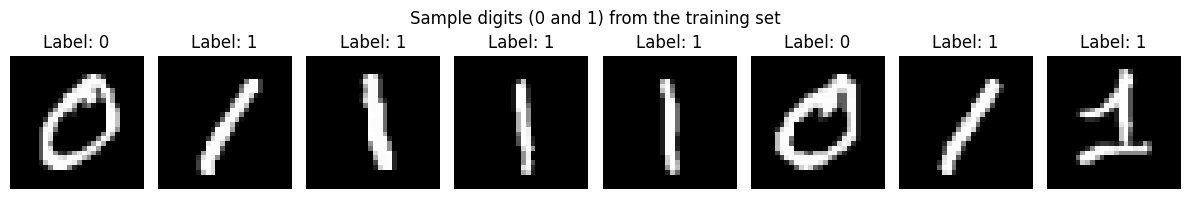

In [3]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Sample digits (0 and 1) from the training set")
plt.tight_layout()
plt.show()

In [4]:
discriminative_model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary output: 0 or 1
], name="discriminative_model")

discriminative_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

discriminative_model.summary()

Model: "discriminative_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,153 (98.25 KB)

 Trainable params: 25,153 (98.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = discriminative_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9950 - loss: 0.0256 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 2/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 4.9003e-04
Epoch 3/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 2.9996e-04
Epoch 4/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 2.4536e-04
Epoch 5/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9998 - loss: 8.6644e-04 - val_accuracy: 1.0000 - val_loss: 2.2492e-04


In [6]:
test_loss, test_acc = discriminative_model.evaluate(x_test, y_test, verbose=0)
print(f"Discriminative model test accuracy: {test_acc:.4f}")

y_pred_prob = discriminative_model.predict(x_test, verbose=0)
y_pred = (y_pred_prob.flatten() > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["Digit 0", "Digit 1"]))

Discriminative model test accuracy: 0.9995
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00       980
     Digit 1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



In [7]:
latent_dim = 16

# Encoder
encoder_input = layers.Input(shape=(784,), name="encoder_input")
x = layers.Dense(128, activation='relu')(encoder_input)
x = layers.Dense(64, activation='relu')(x)
latent = layers.Dense(latent_dim, activation='relu', name="latent")(x)
encoder = models.Model(encoder_input, latent, name="encoder")

# Decoder
decoder_input = layers.Input(shape=(latent_dim,), name="decoder_input")
x = layers.Dense(64, activation='relu')(decoder_input)
x = layers.Dense(128, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)
decoder = models.Model(decoder_input, decoder_output, name="decoder")

# Full autoencoder
autoencoder_input = layers.Input(shape=(784,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)
autoencoder = models.Model(autoencoder_input, decoded, name="autoencoder")

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 16)             │       109,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       110,544 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,320 (860.62 KB)

 Trainable params: 220,320 (860.62 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1695 - val_loss: 0.1149
Epoch 2/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1083 - val_loss: 0.1001
Epoch 3/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0955 - val_loss: 0.0909
Epoch 4/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0888 - val_loss: 0.0865
Epoch 5/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0853 - val_loss: 0.0842
Epoch 6/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0830 - val_loss: 0.0825
Epoch 7/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0813 - val_loss: 0.0813
Epoch 8/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0798 - val_loss: 0.0799
Epoch 9/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0784 - val_loss: 0.0789
Epoch 10/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0774 - val_loss: 0.0780
Epoch 11/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0766 - val_loss: 0.0774
Epoch 12/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

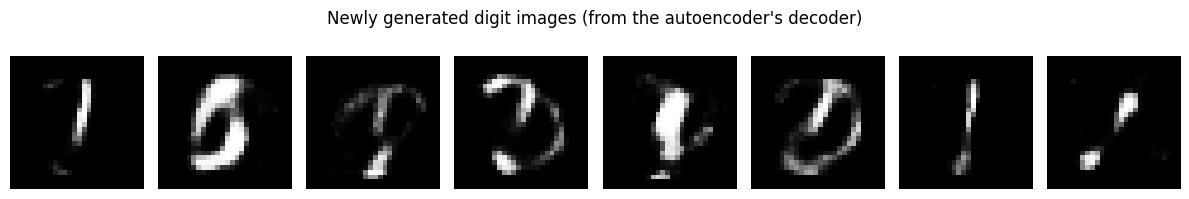

In [9]:
# Sample random points near the real latent distribution so outputs look digit-like
real_latent = encoder.predict(x_train_flat, verbose=0)
latent_mean = real_latent.mean(axis=0)
latent_std = real_latent.std(axis=0)

n_generate = 8
random_latent_vectors = np.random.normal(
    loc=latent_mean, scale=latent_std, size=(n_generate, latent_dim)
)
random_latent_vectors = np.clip(random_latent_vectors, 0, None)  # ReLU latent space is non-negative

generated_images = decoder.predict(random_latent_vectors, verbose=0)
generated_images = generated_images.reshape(-1, 28, 28)

fig, axes = plt.subplots(1, n_generate, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(generated_images[i], cmap='gray')
    ax.axis('off')
plt.suptitle("Newly generated digit images (from the autoencoder's decoder)")
plt.tight_layout()
plt.show()

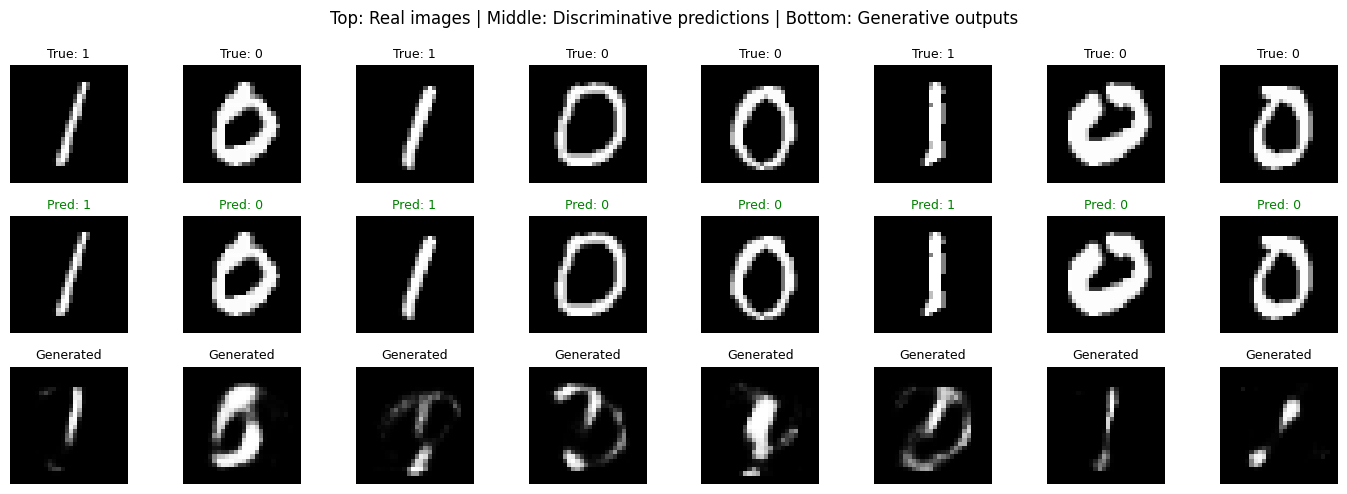


Final discriminative model accuracy: 0.9995


In [10]:
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(14, 5))

# Row 1: Real test images with true labels
for i in range(n_show):
    axes[0, i].imshow(x_test[i], cmap='gray')
    axes[0, i].set_title(f"True: {y_test[i]}", fontsize=9)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel("Real", fontsize=11)

# Row 2: Same images with the discriminative model's predictions
for i in range(n_show):
    axes[1, i].imshow(x_test[i], cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    axes[1, i].set_title(f"Pred: {y_pred[i]}", fontsize=9, color=color)
    axes[1, i].axis('off')
axes[1, 0].set_ylabel("Predicted", fontsize=11)

# Row 3: Freshly generated images from the autoencoder
for i in range(n_show):
    axes[2, i].imshow(generated_images[i % len(generated_images)], cmap='gray')
    axes[2, i].set_title("Generated", fontsize=9)
    axes[2, i].axis('off')
axes[2, 0].set_ylabel("Generated", fontsize=11)

plt.suptitle("Top: Real images | Middle: Discriminative predictions | Bottom: Generative outputs")
plt.tight_layout()
plt.show()

print(f"\nFinal discriminative model accuracy: {test_acc:.4f}")

The discriminative model learned a decision boundary between the two digit classes — it looked at pixel patterns in each image and mapped them directly to a label (0 or 1), without ever needing to understand what a "0" or "1" fundamentally looks like as a whole. The generative model (autoencoder), on the other hand, learned the underlying data distribution of the digit images themselves — the strokes, shapes, and structure that make these digits recognizable — which let it compress an image into a compact latent code and then reconstruct or generate new digit-like images from that code. The key difference is in what each model is trying to do: the discriminative model answers "which class does this belong to?", while the generative model answers "what do these images generally look like, and can I produce more examples like them?" In short, one model separates classes and the other models the data itself.